In [1]:
import sys

sys.path.append("../src/")

import matplotlib.pyplot as plt
import rotations
import torch
from imagegenerator import ImageGenerator
from microscope import Aberration, Detector
from pdb2mrc import PDB2MRC
from plotting_tools import *
from scattering import Scattering, complex_potential
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

## Create 3D scattering potential

In [2]:
# fetch pdb file
pdb_code = "6BDF"
pm = PDB2MRC(pdb_code)
pm.fetch_pdb(pdb_folder="../pdb-data/")

../pdb-data/6BDF
PDB file saved to: ../pdb-data/6BDF.cif


In [3]:
# Samples 3D scattering potential onto specified grid
n = 256  # number of pixels per axis
dx = 1  # angstrom, pixel size.
pm.build_particle(n=n, dx=dx)
V = pm.particle.detach().clone()

100%|█████████████████████████████████████████████| 4/4 [00:02<00:00,  1.46it/s]


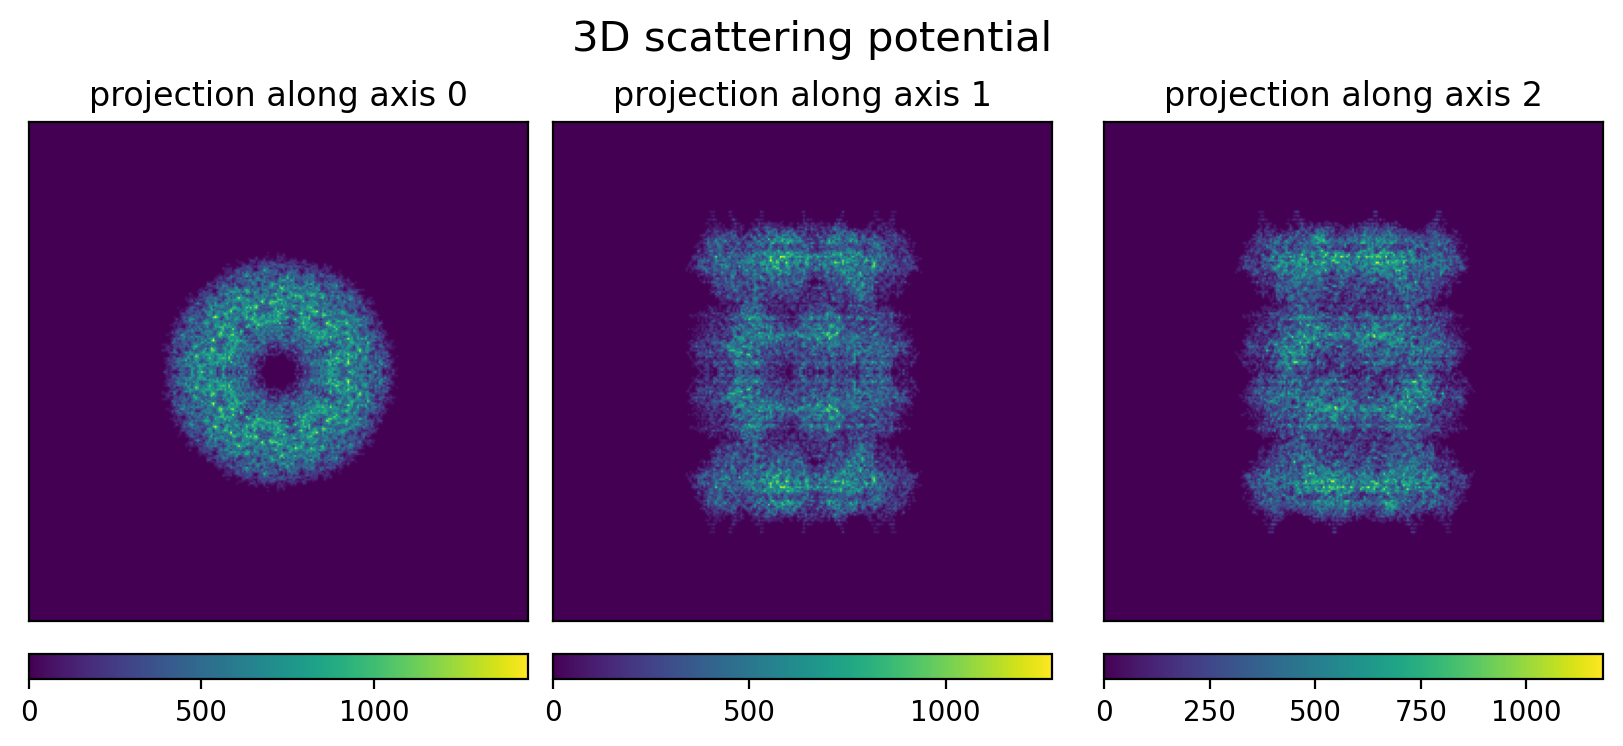

In [4]:
plot3d(V, title="3D scattering potential")

## Manual rotation of 3D scattering potential (if you want)
Only if you want to pre-rotate the 3D potential before simulating images.

Use-case: maybe you want to simulate in-plane rotations of a different view of the particle.

In [5]:
# y-plane rotation for e.g.
rotation_angle = torch.tensor(torch.pi / 2)
rotation_quaternion = torch.tensor(
    [0, torch.sin(rotation_angle / 2), 0, torch.cos(rotation_angle / 2)]
)
rotation_matrix = rotations.quaternion_to_rotation_matrix(
    rotation_quaternion[None, ...]
)
affine_matrix = rotations.build_affine_matrix(rotation_matrix, torch.zeros(1, 3))
rotated_V = rotations.rotate_volume(V, affine_matrix)

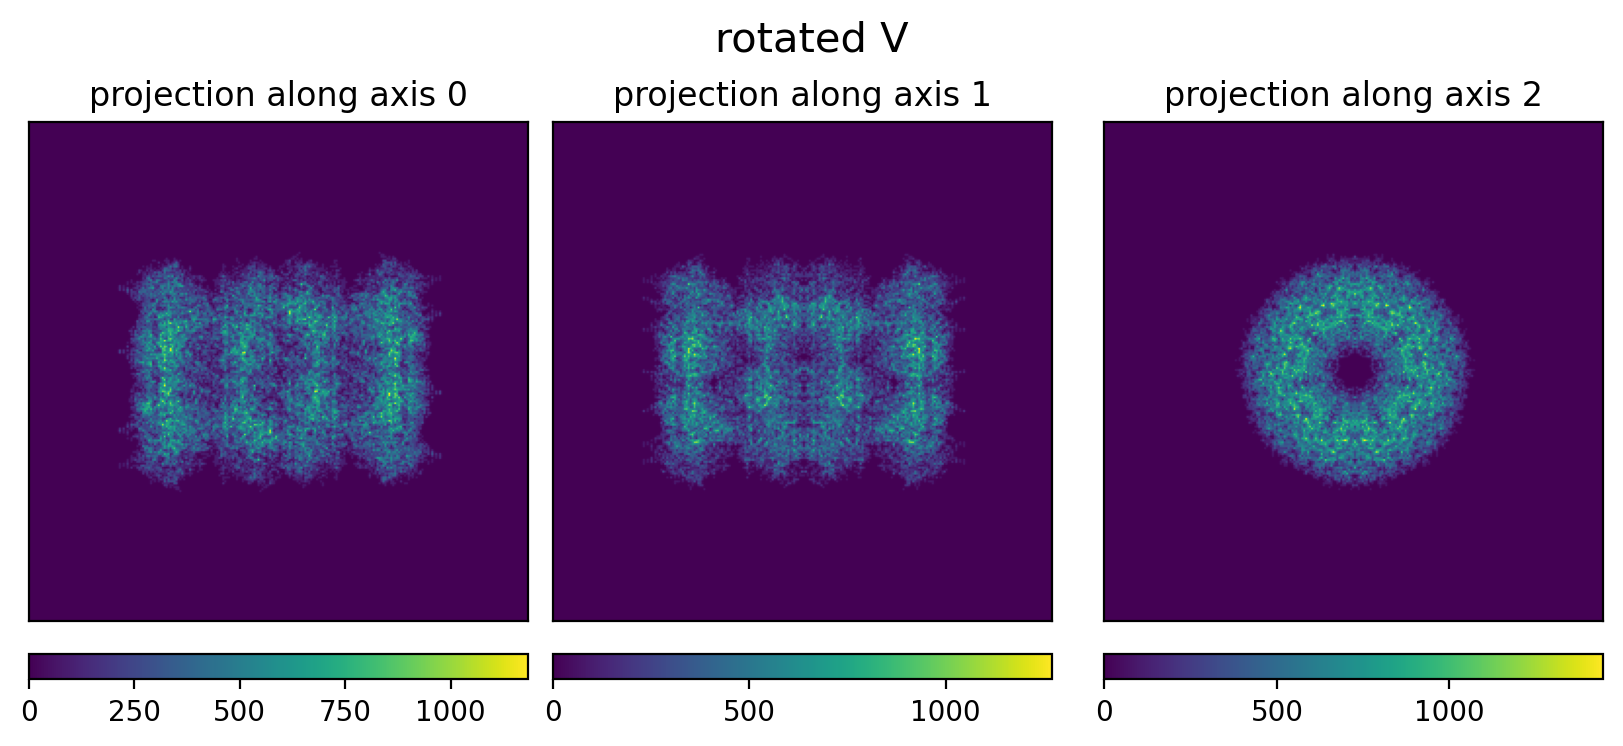

In [6]:
plot3d(rotated_V.squeeze(), title="rotated V")

## Generate dataset
Here, you can choose to either use random or in-plane rotations, and random or fixed defocus values (comment/uncomment respectively).

In [5]:
n_particles = 20
energy = 200  # keV
dose_per_angstrom = 20  # e-/A^2
Cs = 2e7  # angstrom. Sherical aberration, typical values are 1-3 mm.
alpha = 0.1

In [6]:
# random quaternions
quaternions = torch.stack([rotations.random_quaternion() for i in range(n_particles)])

# in-plane rotations (around z-axis)
# angles = torch.linspace(0, 360, n_particles + 1)
# angles = angles[:-1] / 180 * torch.pi
# quaternions = []
# for a in angles:
#     # (x,y,z,w)
#     quaternions.append(torch.tensor([0, 0, torch.sin(a / 2), torch.cos(a / 2)]))
# quaternions = torch.stack(quaternions)

quaternions.shape

torch.Size([20, 4])

In [7]:
# random defocus
defocus_min = 2000  # angstrom
defocus_max = 9000  # angstrom
dfang = 0
defocus_A = torch.rand(n_particles) * (defocus_max - defocus_min) + defocus_min

# fixed defocus
# defocus_A = 10000 * torch.ones(n_particles)

# beamtilt
tiltx = 0.
tilty = 0.

# phaseshift
phaseshift = 0

# [Cs, dfu, dfv, dfang, tiltx, tilty, phaseshift]
ctf_params = torch.stack(
    [torch.tensor([Cs, d, d, dfang, tiltx, tilty, phaseshift]) for d in defocus_A]
)
ctf_params.shape

torch.Size([20, 7])

In [8]:
# random shift. set to 0 for no shifts
shift = 0.15  # A
rlnOriginXAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
rlnOriginYAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
translations = torch.stack([rlnOriginXAngst, rlnOriginYAngst], dim=-1)
translations.shape

torch.Size([20, 2])

In [13]:
device = "cuda:1"  # choose cpu if you run out of cuda memory.

In [14]:
# Use multislice, holography, poisson and random_choice to obtain close to experimental conditions.
scattering_model = "multislice"  # 'multislice', 'firstborn', 'projection', 'ctf'
aberration_model = "holography"  # 'holography' or 'ctf'
noise_model = "poisson"  # 'poisson' or None
ice_model = "randomchoice"  # 'randomchoice' or None
ice_thickness = 1000 # angstroms

model = ImageGenerator(
    V,  # or rotated_V
    dx,
    quaternions,
    translations,
    ctf_params,
    energy,
    dose_per_angstrom,
    ice_model=ice_model,
    ice_thickness=ice_thickness,
    scattering_model=scattering_model,
    aberration_model=aberration_model,
    noise_model=noise_model,
    klim=None,
    flip_curvature=False,
    alpha=alpha,
).to(device)

In [17]:
idx = torch.arange(n)
images = []
batchsize = 5  # set higher or lower for faster/slower generation.
with torch.no_grad():
    for i in tqdm(range(0, n_particles, batchsize)):
        image = model(idx[i : i + batchsize])
        images.append(image.detach().cpu())

images = torch.concat(images, dim=0)
images.shape

100%|█████████████████████████████████████████████| 4/4 [00:07<00:00,  1.85s/it]


torch.Size([20, 256, 256])

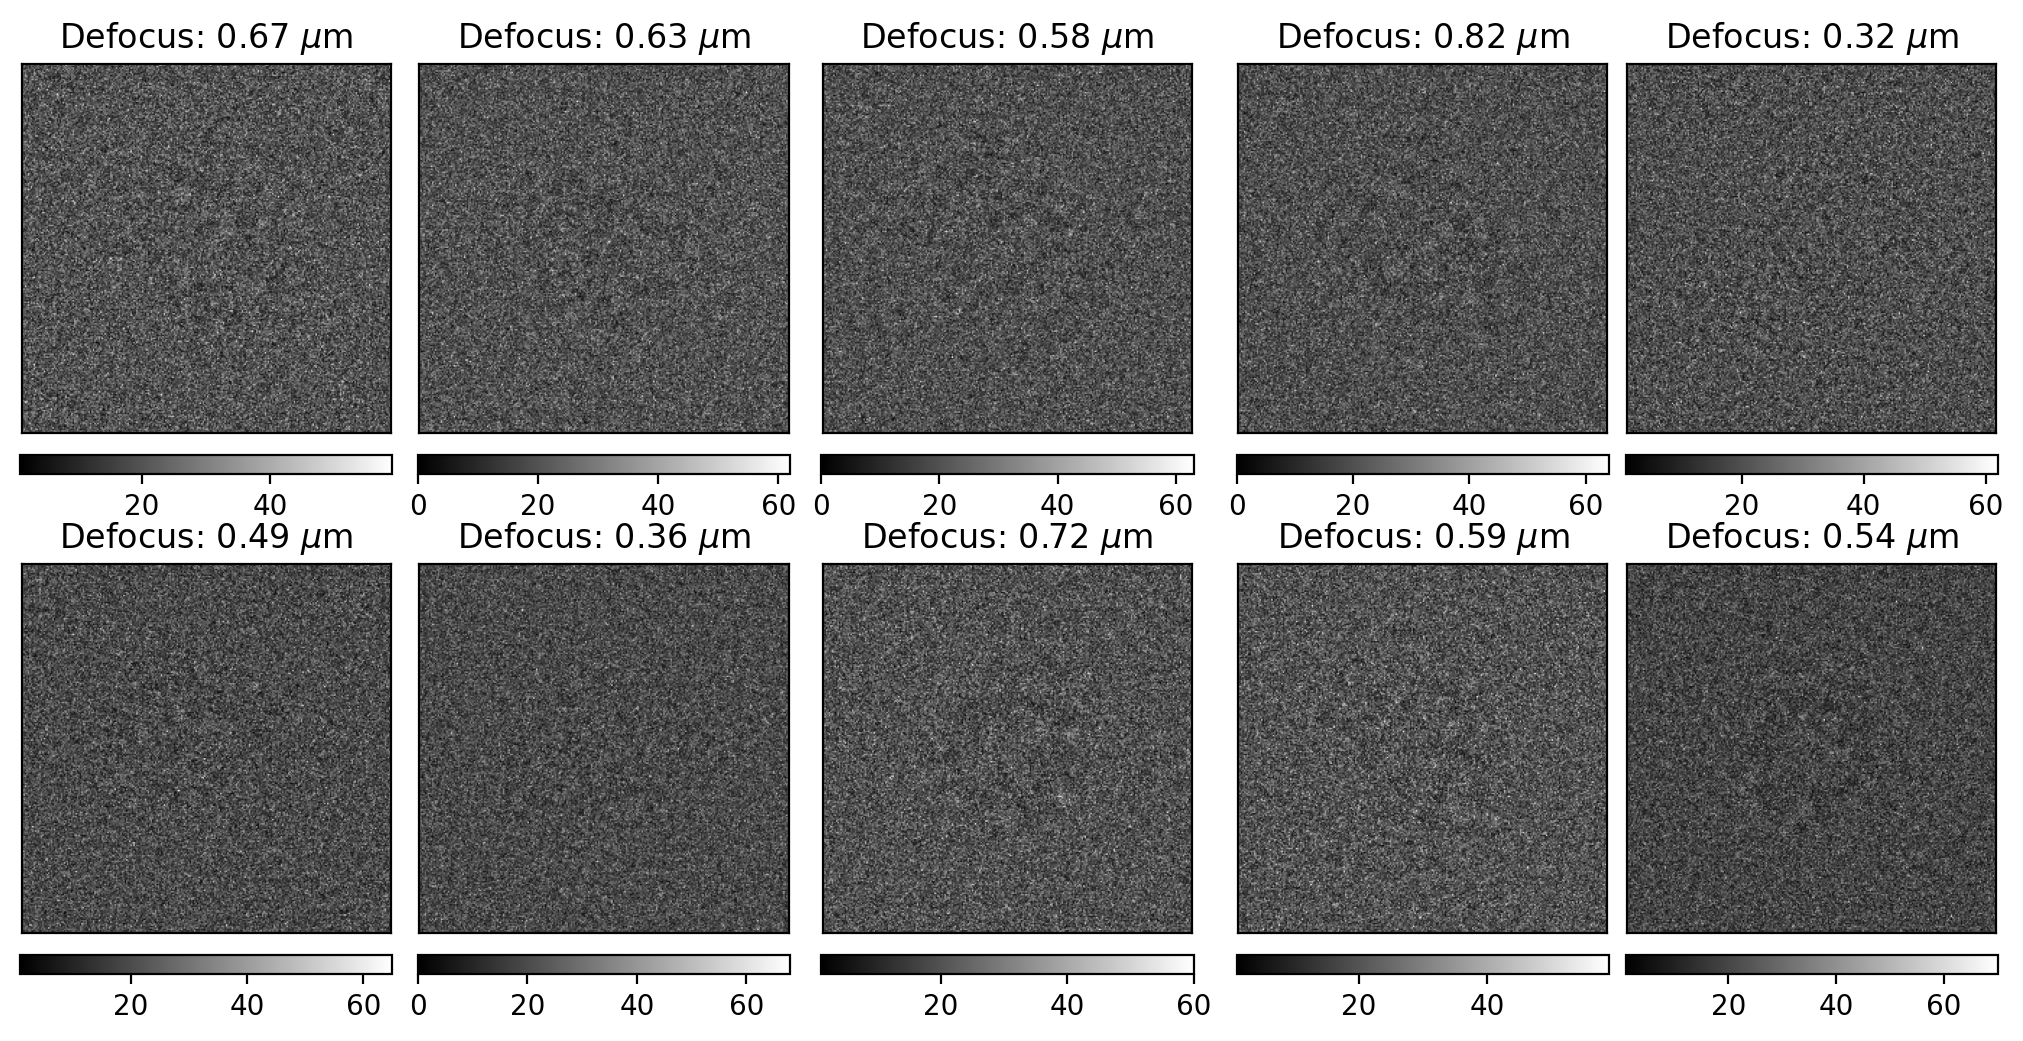

In [18]:
fig, axes = plt.subplots(2, 5, dpi=200, constrained_layout=True, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(images[i], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params[i,2]/10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")
plt.show()